# Train Localization Decoder

Trains the CNN decoder on pre-extracted V-JEPA 2 patch embeddings.  
Runs on **Mac (MPS)**, **Kaggle GPU**, or CPU — no V-JEPA weights needed here.

**Prerequisite:** run `embed_dataset_kaggle.ipynb` first to produce  
`Bmingg/cs280-synthetic-circles-v2-embeddings-vjepa2` on HuggingFace.

Pipeline:
```
[B, 1024, 16, 16] embedding
  → UpsampleBlock(1024→512)  16 → 32
  → UpsampleBlock(512→256)   32 → 64
  → UpsampleBlock(256→128)   64 → 128
  → UpsampleBlock(128→64)   128 → 256
  → Conv1×1 + Sigmoid       → [B, 1, 256, 256] heatmap
```

## 1. Imports & Constants

In [1]:
import math
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 13
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def _get_device() -> torch.device:
    if torch.cuda.is_available():
        cap = torch.cuda.get_device_capability()
        if cap[0] >= 7:
            return torch.device('cuda')
        print(f'WARNING: GPU sm_{cap[0]}{cap[1]} < sm_70 — falling back to CPU. Switch to T4.')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = _get_device()

IMAGE_SIZE = 384
PATCH_GRID = 24
EMBED_DIM  = 1408



COLOR_NAMES = {0: 'red', 1: 'green', 2: 'blue'}

HF_EMB_REPO   = 'Bmingg/cs280-synthetic-circles-v2-embeddings-vjepa21-vitg-384'
HF_MODEL_REPO = 'Bmingg/decoder-vjepa21-vitg-384_2'

CKPT_DIR = Path('/checkpoints') if Path('/kaggle').exists() \
           else Path('../outputs/checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_EVERY = 5

print(f'Device       : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
print(f'Checkpoints  : {CKPT_DIR}')
print(f'HF model repo: {HF_MODEL_REPO}')

Device       : cuda
GPU          : NVIDIA RTX PRO 6000 Blackwell Server Edition
Checkpoints  : /checkpoints
HF model repo: Bmingg/cs280-localization-decoder-vjepa21-vitg-384


## 2. Load Embeddings from HuggingFace

In [5]:
from datasets import load_dataset

hf_emb = load_dataset(HF_EMB_REPO, split='train')
print(hf_emb)
print(f'Columns: {hf_emb.column_names}')

sample = hf_emb[0]
emb_sample = np.array(sample['embedding'])
print(f'\nEmbedding shape: {emb_sample.shape}  dtype: {emb_sample.dtype}')
print(f'cx={sample["cx"]}  cy={sample["cy"]}  radius={sample["radius"]}  color={COLOR_NAMES[sample["color"]]}')

README.md:   0%|          | 0.00/502 [00:00<?, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

...

data/train-00005-of-00008.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00006-of-00008.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00007-of-00008.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['embedding', 'cx', 'cy', 'radius', 'color'],
    num_rows: 2000
})
Columns: ['embedding', 'cx', 'cy', 'radius', 'color']

Embedding shape: (1408, 24, 24)  dtype: float64
cx=46  cy=319  radius=42  color=blue


## 3. Dataset — Embeddings + On-the-Fly Heatmaps

Heatmaps are regenerated from `(cx, cy, radius)` at load time — they are not stored in the HF dataset.

In [6]:
def make_gaussian_heatmap(h: int, w: int, cx: float, cy: float, sigma: float) -> np.ndarray:
    xs = np.arange(w, dtype=np.float32)
    ys = np.arange(h, dtype=np.float32)
    xg, yg = np.meshgrid(xs, ys)
    return np.exp(-((xg - cx)**2 + (yg - cy)**2) / (2 * sigma**2)).astype(np.float32)


# Source dataset was generated at 384px; embeddings are 256px — scale coordinates to match.
_COORD_SCALE = 1.0


class EmbeddingDataset(Dataset):
    """
    Wraps Bmingg/cs280-synthetic-circles-v2-embeddings-vjepa2.
    Returns:
        embedding : FloatTensor [1024, 16, 16]  float32
        heatmap   : FloatTensor [1, 256, 256]
        meta      : dict{cx, cy, r, color}  — coords already scaled to 256px space
    """
    def __init__(self, hf_dataset, image_size=IMAGE_SIZE, sigma_factor=1.5):
        self.ds = hf_dataset
        self.H = self.W = image_size
        self.sf = sigma_factor

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        row = self.ds[idx]
        cx, cy, r, color = row['cx'], row['cy'], row['radius'], row['color']
        # cx/cy/r are in 384px coordinate space — scale down to match 256px embeddings
        cx_s = cx * _COORD_SCALE
        cy_s = cy * _COORD_SCALE
        r_s  = r  * _COORD_SCALE
        emb = torch.from_numpy(np.array(row['embedding'])).float()
        hm  = make_gaussian_heatmap(self.H, self.W, cx_s, cy_s, self.sf * r_s)
        return emb, torch.from_numpy(hm).unsqueeze(0), {'cx': cx_s, 'cy': cy_s, 'r': r_s, 'color': color}


full_ds = EmbeddingDataset(hf_emb)
emb, hm, meta = full_ds[0]
print(f'embedding: {emb.shape}  heatmap: {hm.shape}  color: {COLOR_NAMES[meta["color"]]}')
print(f'Sample cx={meta["cx"]:.1f}  cy={meta["cy"]:.1f}  r={meta["r"]:.1f}  (scaled from 384px to 256px)')

embedding: torch.Size([1408, 24, 24])  heatmap: torch.Size([1, 384, 384])  color: blue
Sample cx=46.0  cy=319.0  r=42.0  (scaled from 384px to 256px)


## 4. Localization Decoder

Architecture matches Table 1 of the paper: four `3×3, Stride 2` transposed-conv blocks.

In [7]:
class UpsampleBlock(nn.Module):
    """3×3 ConvTranspose2d ×2 + BN + ReLU (matches Table 1 of the paper)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=3, stride=2,
                               padding=1, output_padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class LocalizationDecoder(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.upsample = nn.Sequential(
            UpsampleBlock(embed_dim, 512),   # 16  → 32
            UpsampleBlock(512, 256),          # 32  → 64
            UpsampleBlock(256, 128),          # 64  → 128
            UpsampleBlock(128, 64),           # 128 → 256
        )
        self.head = nn.Sequential(
            nn.Conv2d(64, 1, kernel_size=1),
            nn.Sigmoid(),
        )
    def forward(self, x): return self.head(self.upsample(x))


decoder = LocalizationDecoder().to(DEVICE)
dummy   = torch.zeros(2, EMBED_DIM, PATCH_GRID, PATCH_GRID).to(DEVICE)
print(f'Decoder output : {decoder(dummy).shape}')   # [2, 1, 256, 256]
print(f'Parameters     : {sum(p.numel() for p in decoder.parameters()):,}')

Decoder output : torch.Size([2, 1, 384, 384])
Parameters     : 8,039,297


## 5. Loss & Metrics

In [8]:
class HeatmapLoss(nn.Module):
    """MSE + optional focal-BCE term."""
    def __init__(self, mse_weight=1.0, focal_weight=0.0, gamma=2.0):
        super().__init__()
        self.mse_w = mse_weight; self.focal_w = focal_weight; self.gamma = gamma
        self._mse  = nn.MSELoss()
    def forward(self, pred, target):
        loss = self.mse_w * self._mse(pred, target)
        if self.focal_w > 0:
            bce  = F.binary_cross_entropy(pred, target, reduction='none')
            pt   = torch.where(target > 0.5, pred, 1 - pred)
            loss = loss + self.focal_w * ((1 - pt) ** self.gamma * bce).mean()
        return loss


def heatmap_peak(hm):
    h, w = hm.shape[-2], hm.shape[-1]
    idx  = hm.squeeze().argmax().item()
    return int(idx) % w, int(idx) // w

def center_error(pred_hm, gt_cx, gt_cy):
    px, py = heatmap_peak(pred_hm)
    return math.sqrt((px - gt_cx)**2 + (py - gt_cy)**2)

def iou_heatmap(pred_hm, gt_hm, threshold=0.5):
    pb = pred_hm.squeeze() >= threshold
    gb = gt_hm.squeeze()   >= threshold
    inter = (pb & gb).sum().item(); union = (pb | gb).sum().item()
    return inter / union if union > 0 else 0.0

print('Loss and metrics defined.')

Loss and metrics defined.


## 6. Train / Val Split & DataLoaders

In [9]:
N_TRAIN    = 1800
N_VAL      = len(full_ds) - N_TRAIN
BATCH_SIZE = 32 if DEVICE.type in ('cuda', 'mps') else 16
EPOCHS     = 30
LR         = 1e-3

train_ds, val_ds = random_split(
    full_ds, [N_TRAIN, N_VAL],
    generator=torch.Generator().manual_seed(SEED),
)

# num_workers=0 on Mac (MPS doesn't support fork); 2 on Kaggle
nw = 0 if DEVICE.type == 'mps' else 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=nw, pin_memory=(DEVICE.type == 'cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=nw, pin_memory=(DEVICE.type == 'cuda'))

decoder   = LocalizationDecoder().to(DEVICE)
optimizer = torch.optim.Adam(decoder.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
loss_fn   = HeatmapLoss(mse_weight=1.0)

print(f'Train: {N_TRAIN}  Val: {N_VAL}  Batch: {BATCH_SIZE}  Device: {DEVICE}')
print(f'Batches per epoch — train: {len(train_loader)}  val: {len(val_loader)}')
print(f'Saving every {SAVE_EVERY} epochs + best (by val centre error) → {CKPT_DIR}')

Train: 1800  Val: 200  Batch: 32  Device: cuda
Batches per epoch — train: 57  val: 7
Saving every 5 epochs + best (by val centre error) → ../outputs/checkpoints


## 7. Training Loop

In [10]:
def run_epoch(loader, decoder, loss_fn, optimizer=None):
    training = optimizer is not None
    decoder.train(training)
    total_loss = total_ce = total_iou = 0.0
    n = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for embs, heatmaps, metas in loader:
            embs     = embs.to(DEVICE, non_blocking=True)
            heatmaps = heatmaps.to(DEVICE, non_blocking=True)
            pred     = decoder(embs)
            loss     = loss_fn(pred, heatmaps)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * embs.size(0)
            pred_cpu = pred.detach().cpu(); gt_cpu = heatmaps.cpu()
            for i in range(embs.size(0)):
                total_ce  += center_error(pred_cpu[i], metas['cx'][i].item(), metas['cy'][i].item())
                total_iou += iou_heatmap(pred_cpu[i], gt_cpu[i])
            n += embs.size(0)
    return total_loss / n, total_ce / n, total_iou / n


def save_checkpoint(path, epoch, decoder, optimizer, scheduler, metrics):
    torch.save({
        'epoch':               epoch,
        'decoder_state_dict':  decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'embed_dim':           EMBED_DIM,
        'image_size':          IMAGE_SIZE,
        'val_loss':            metrics['val_loss'],
        'val_ce':              metrics['val_ce'],
        'val_iou':             metrics['val_iou'],
    }, path)


# Best tracked by val centre error (pixels) — most interpretable localization metric
best_val_ce   = float('inf')
best_ckpt_path = CKPT_DIR / 'decoder_best.pt'

train_losses, val_losses = [], []
train_ces,    val_ces    = [], []
train_ious,   val_ious   = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_ce, tr_iou = run_epoch(train_loader, decoder, loss_fn, optimizer)
    vl_loss, vl_ce, vl_iou = run_epoch(val_loader,   decoder, loss_fn)
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_ces.append(tr_ce);      val_ces.append(vl_ce)
    train_ious.append(tr_iou);    val_ious.append(vl_iou)

    metrics = {'val_loss': vl_loss, 'val_ce': vl_ce, 'val_iou': vl_iou}

    # Periodic checkpoint every SAVE_EVERY epochs
    if epoch % SAVE_EVERY == 0:
        periodic_path = CKPT_DIR / f'decoder_epoch{epoch:03d}.pt'
        save_checkpoint(periodic_path, epoch, decoder, optimizer, scheduler, metrics)
        print(f'  → saved periodic checkpoint: {periodic_path.name}')

    # Best checkpoint by val centre error
    if vl_ce < best_val_ce:
        best_val_ce = vl_ce
        save_checkpoint(best_ckpt_path, epoch, decoder, optimizer, scheduler, metrics)
        marker = '  ★ best'
    else:
        marker = ''

    print(f'Epoch {epoch:02d}/{EPOCHS}  lr={scheduler.get_last_lr()[0]:.2e}  '
          f'train loss={tr_loss:.4f} CE={tr_ce:.1f}px IoU={tr_iou:.3f}  |  '
          f'val loss={vl_loss:.4f} CE={vl_ce:.1f}px IoU={vl_iou:.3f}{marker}')

print(f'\nBest val CE: {best_val_ce:.1f}px  →  {best_ckpt_path}')

Epoch 01/30  lr=9.97e-04  train loss=0.0866 CE=24.4px IoU=0.544  |  val loss=0.0282 CE=20.1px IoU=0.741  ★ best
Epoch 02/30  lr=9.89e-04  train loss=0.0144 CE=15.5px IoU=0.798  |  val loss=0.0079 CE=12.1px IoU=0.807  ★ best
Epoch 03/30  lr=9.76e-04  train loss=0.0062 CE=10.5px IoU=0.818  |  val loss=0.0040 CE=11.7px IoU=0.850  ★ best
Epoch 04/30  lr=9.57e-04  train loss=0.0036 CE=10.3px IoU=0.835  |  val loss=0.0025 CE=11.4px IoU=0.850  ★ best
  → saved periodic checkpoint: decoder_epoch005.pt
Epoch 05/30  lr=9.33e-04  train loss=0.0023 CE=10.5px IoU=0.855  |  val loss=0.0018 CE=11.6px IoU=0.869
Epoch 06/30  lr=9.05e-04  train loss=0.0020 CE=10.6px IoU=0.846  |  val loss=0.0018 CE=11.3px IoU=0.860  ★ best
Epoch 07/30  lr=8.72e-04  train loss=0.0015 CE=10.8px IoU=0.857  |  val loss=0.0012 CE=12.3px IoU=0.877
Epoch 08/30  lr=8.35e-04  train loss=0.0014 CE=11.3px IoU=0.857  |  val loss=0.0011 CE=11.0px IoU=0.880  ★ best
Epoch 09/30  lr=7.94e-04  train loss=0.0011 CE=10.7px IoU=0.870  |  v

## 8. Training Curves

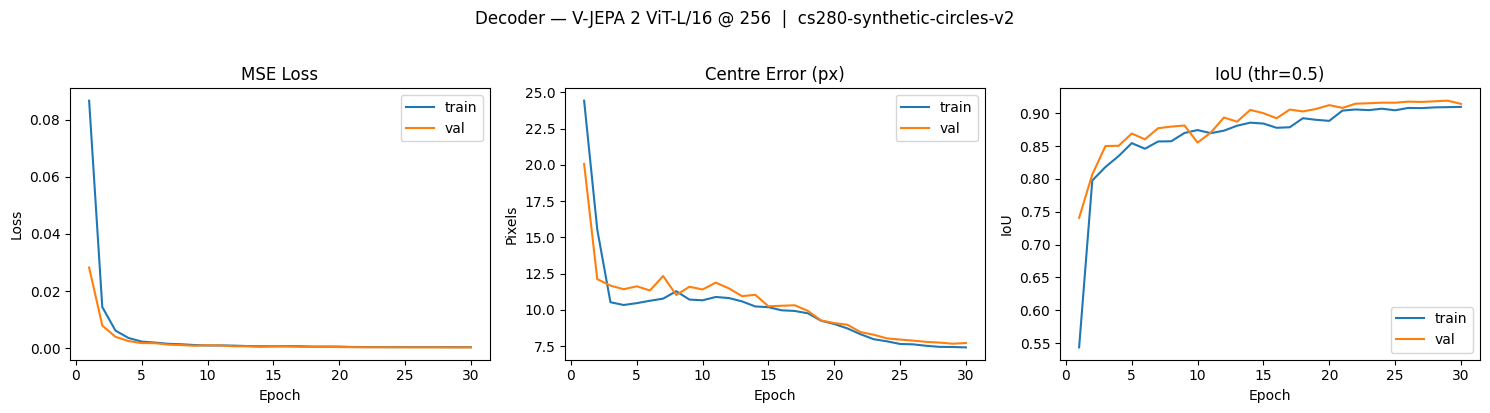

In [14]:
er = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, tr, vl, title, ylabel in zip(
    axes,
    [train_losses, train_ces, train_ious],
    [val_losses,   val_ces,   val_ious],
    ['MSE Loss', 'Centre Error (px)', 'IoU (thr=0.5)'],
    ['Loss', 'Pixels', 'IoU'],
):
    ax.plot(er, tr, label='train')
    ax.plot(er, vl, label='val')
    ax.set(title=title, xlabel='Epoch', ylabel=ylabel)
    ax.legend()
plt.suptitle('Decoder — V-JEPA 2 ViT-L/16 @ 256  |  cs280-synthetic-circles-v2', y=1.02)
plt.savefig( '../ training_curves.png', bbox_inches='tight')
plt.tight_layout(); plt.show()

## 9. Qualitative Results

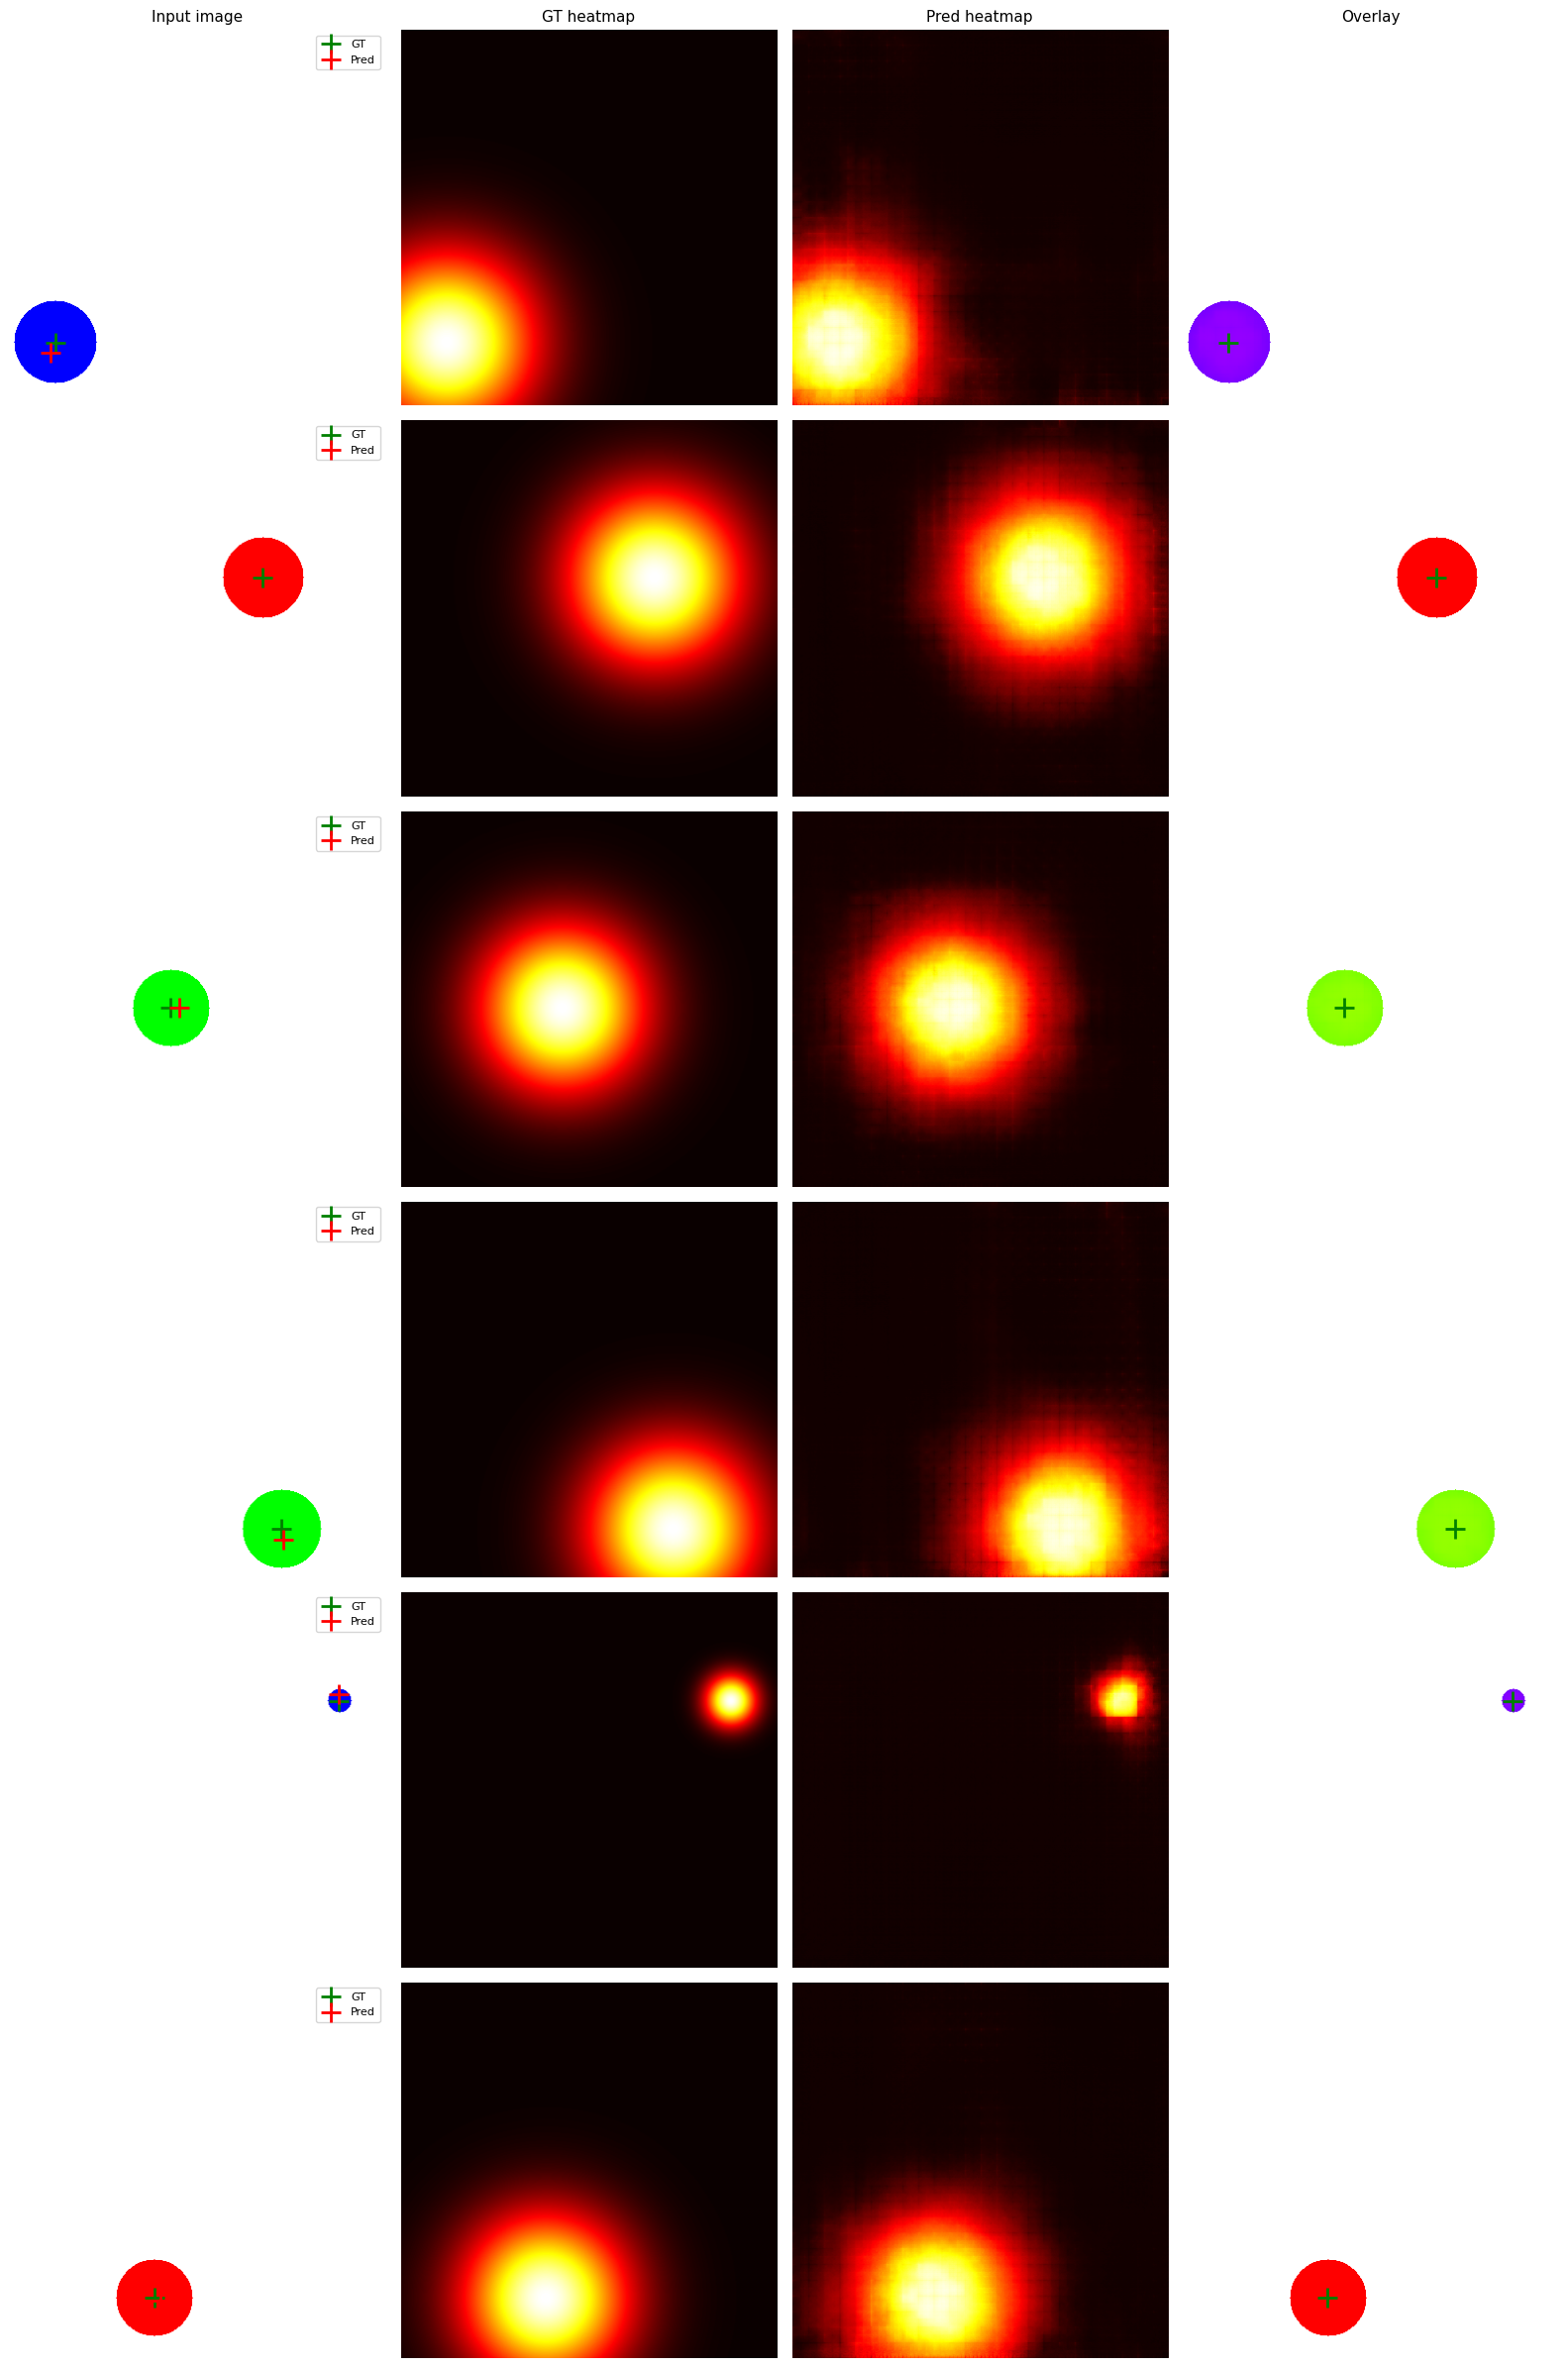

In [15]:
from datasets import load_dataset as _ld
hf_src = _ld('Bmingg/cs280-synthetic-circles-v2', split='train')

# Load best checkpoint
ckpt = torch.load('../outputs/checkpoints/decoder_best.pt', weights_only=True)
decoder.load_state_dict(ckpt['decoder_state_dict'])
decoder.eval()

N_SHOW = 6
fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, 4 * N_SHOW))
for col, title in enumerate(['Input image', 'GT heatmap', 'Pred heatmap', 'Overlay']):
    axes[0, col].set_title(title, fontsize=11)

with torch.no_grad():
    for row in range(N_SHOW):
        emb, gt_hm, meta = full_ds[row]
        pred_hm = decoder(emb.unsqueeze(0).to(DEVICE)).squeeze().cpu()

        cx, cy = meta['cx'], meta['cy']
        pred_cx, pred_cy = heatmap_peak(pred_hm.unsqueeze(0))
        ce = center_error(pred_hm.unsqueeze(0), cx, cy)

        img_np = np.array(hf_src[row]['image'].resize((IMAGE_SIZE, IMAGE_SIZE))).astype(np.float32) / 255.0
        pr_np  = pred_hm.numpy()
        gt_np  = gt_hm.squeeze().numpy()

        axes[row, 0].imshow(img_np)
        axes[row, 0].plot(cx, cy, 'g+', ms=14, mew=2, label='GT')
        axes[row, 0].plot(pred_cx, pred_cy, 'r+', ms=14, mew=2, label='Pred')
        axes[row, 0].set_ylabel(f'CE={ce:.1f}px  [{COLOR_NAMES[meta["color"]]}]', fontsize=9)
        axes[row, 0].legend(loc='upper right', fontsize=8)
        axes[row, 1].imshow(gt_np, cmap='hot', vmin=0, vmax=1)
        axes[row, 2].imshow(pr_np, cmap='hot', vmin=0, vmax=1)
        overlay = img_np.copy()
        overlay[:, :, 0] = np.clip(overlay[:, :, 0] + pr_np * 0.6, 0, 1)
        axes[row, 3].imshow(overlay)
        axes[row, 3].plot(cx, cy, 'g+', ms=14, mew=2)
        for ax in axes[row]: ax.axis('off')

plt.tight_layout(); plt.show()

## 10. Checkpoint Info

In [18]:
from huggingface_hub import HfApi, login

# Uncomment and paste your token if not already logged in:
# login(token='hf_...')

size_mb = best_ckpt_path.stat().st_size / 1e6
print(f'Best checkpoint : {best_ckpt_path}')
print(f'Size            : {size_mb:.1f} MB')
print(f'Best val CE     : {best_val_ce:.1f} px')

ckpt_info = torch.load(best_ckpt_path, weights_only=True)
print(f'Saved at epoch  : {ckpt_info["epoch"]}')
print(f'Val loss        : {ckpt_info["val_loss"]:.4f}')
print(f'Val IoU         : {ckpt_info["val_iou"]:.3f}')

print(f'\nPushing best checkpoint to {HF_MODEL_REPO} ...')
api = HfApi()
api.create_repo(HF_MODEL_REPO, repo_type='model', exist_ok=True)
api.upload_file(
    path_or_fileobj=str(best_ckpt_path),
    path_in_repo='decoder_best.pt',
    repo_id=HF_MODEL_REPO,
    repo_type='model',
    commit_message=f'Best decoder — val CE={best_val_ce:.1f}px  IoU={ckpt_info["val_iou"]:.3f}  epoch={ckpt_info["epoch"]}',
)
print(f'Done — https://huggingface.co/{HF_MODEL_REPO}')

# List all local checkpoints saved this run
print('\nAll local checkpoints:')
for p in sorted(CKPT_DIR.glob('*.pt')):
    print(f'  {p.name}  ({p.stat().st_size/1e6:.1f} MB)')

Best checkpoint : ../outputs/checkpoints/decoder_best.pt
Size            : 96.5 MB
Best val CE     : 7.7 px
Saved at epoch  : 29
Val loss        : 0.0003
Val IoU         : 0.919

Pushing best checkpoint to Bmingg/cs280-localization-decoder-vjepa21-vitg-384 ...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Done — https://huggingface.co/Bmingg/cs280-localization-decoder-vjepa21-vitg-384

All local checkpoints:
  decoder_best.pt  (96.5 MB)
  decoder_epoch005.pt  (96.5 MB)
  decoder_epoch010.pt  (96.5 MB)
  decoder_epoch015.pt  (96.5 MB)
  decoder_epoch020.pt  (96.5 MB)
  decoder_epoch025.pt  (96.5 MB)
  decoder_epoch030.pt  (96.5 MB)


In [ ]:
import zipfile

zip_path = CKPT_DIR.parent / 'checkpoints.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(CKPT_DIR.glob('*.pt')):
        zf.write(p, arcname=p.name)

zip_mb = zip_path.stat().st_size / 1e6
print(f'Zipped all checkpoints → {zip_path}  ({zip_mb:.1f} MB)')
print('Download from Kaggle → Output tab → checkpoints.zip')